## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [3]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

In [4]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [5]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)

# # plt.plot(omega,spec1BW,label=r'1 BW peak')
# plt.plot(omega,spec2BW, label=r'2 BW peaks')
# #plt.plot(omega,spec3BW, label=r'3 BW peaks')

# plt.legend()
# plt.xlim(0,10)


In [6]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
# kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
# klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

# ##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
# Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

In [5]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop
from multiprocessing import Pool


# Create input data and target
 # Constant input node which goes to 500 omegas as the NN structure in paper
# target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 1.0e-2
lambda_l2_warmup = 1.0e-4
lambda_s = 1.0e-5#1.0e-4
lambda_l2 = 1.0e-8
epochs=2000
new_epochs = 20000

num_samples = 30
gauss_width = np.ones(len(x)) #for mean square error
Dxi_ensemble=[]
noisy_Dxi_ensemble=[]
rho_ensemble=[]
total_loss_history_ensemble=[]
loss_history_ensemble=[]

def func(i):
    import models
    import lossCalculator
    import correlator
    import tensorflow as tf
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    # constant_input = tf.constant(omega, dtype=tf.float32)  #NNP2p
    # constant_input = tf.reshape(constant_input, (-1, 1)) #NNP2p
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    kern=klW_ker_Pos
    Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)
    ep_noise=3e-2
    noisy_dxi_tensor = []
    num_samples = 1
    noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
    gauss_width=custom_std
    model = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
    target_output = tf.constant(noisy_Dxi, dtype=tf.float32)
    lossCalc=lossCalculator.LossCalculator(model=model,
                                        y_true=target_output,
                                        kernel=kern,
                                        delomega=del_omega,
                                        x=constant_input,
                                        std=gauss_width,
                                        lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                        lambda_s_func=lambda x:lambda_s,
                                        lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                        lambda_l2_func=lambda x:lambda_l2
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)
    rho=model(constant_input)
    return Dxi.numpy(),noisy_Dxi.numpy(),rho.numpy(),total_loss_history,loss_history


pool=Pool(15)
Dxi_ensemble,noisy_Dxi_ensemble,rho_ensemble,total_loss_history_ensemble,loss_history_ensemble=zip(*pool.map(func,range(num_samples)))

# results.wait()

pool.close()
Dxi_ensemble=np.array(Dxi_ensemble)
noisy_Dxi_ensemble=np.array(noisy_Dxi_ensemble)
rho_ensemble=np.array(rho_ensemble)
total_loss_history_ensemble=np.array(total_loss_history_ensemble)
loss_history_ensemble=np.array(loss_history_ensemble)




2024-12-04 17:12:47.492617: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 17:12:47.492617: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 17:12:47.492617: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 17:12:47.492617: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochsTraining for 2000 epochs

Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs


2024-12-04 17:12:48.530356: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:48.531183: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:48.548401: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:48.559485: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:48.563691: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:48.569058: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Epoch 0, Loss: 749.8347778320312
Epoch 0, Loss: 748.5555419921875
Epoch 0, Loss: 751.837890625
Epoch 0, Loss: 749.6019287109375
Epoch 0, Loss: 750.6661987304688
Epoch 0, Loss: 749.4793090820312
Epoch 0, Loss: 739.193603515625
Epoch 0, Loss: 750.4586181640625
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs


2024-12-04 17:12:48.928670: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:49.026951: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:49.045419: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:49.054654: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:49.060094: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 17:12:49.071503: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Epoch 0, Loss: 749.0533447265625
Epoch 0, Loss: 755.418701171875
Epoch 0, Loss: 749.62890625
Epoch 0, Loss: 752.3033447265625
Epoch 0, Loss: 746.448486328125
Epoch 0, Loss: 743.0137329101562
Training for 2000 epochs


2024-12-04 17:12:49.286778: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 0, Loss: 755.0077514648438
Epoch 200, Loss: 0.06247386708855629
Epoch 200, Loss: 0.05886514484882355
Epoch 200, Loss: 0.08889847248792648
Epoch 200, Loss: 0.08468255400657654
Epoch 200, Loss: 0.07076447457075119
Epoch 200, Loss: 0.05061102285981178
Epoch 200, Loss: 0.11185251921415329
Epoch 200, Loss: 0.04697686433792114
Epoch 200, Loss: 0.06282555311918259
Epoch 400, Loss: 0.010251653380692005
Epoch 400, Loss: 0.009437531232833862
Epoch 400, Loss: 0.014763610437512398
Epoch 400, Loss: 0.01104427408427
Epoch 200, Loss: 0.05596647039055824
Epoch 200, Loss: 0.043158113956451416
Epoch 200, Loss: 0.05514872446656227
Epoch 200, Loss: 0.10074873268604279
Epoch 400, Loss: 0.00811011716723442
Epoch 400, Loss: 0.01701953448355198
Epoch 400, Loss: 0.010260326787829399
Epoch 400, Loss: 0.01293464656919241
Epoch 200, Loss: 0.058707885444164276
Epoch 200, Loss: 0.05721096321940422
Epoch 400, Loss: 0.008280117996037006
Epoch 600, Loss: 0.003110380144789815
Epoch 600, Loss: 0.00398253882303834


2024-12-04 17:17:34.888300: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 17:17:34.889075: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-04 17:17:34.891919: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-04 17:17:34.900865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733329054.917066   54498 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733329054.92

Epoch 14000, Loss: 2.365554428251926e-05
Epoch 18000, Loss: 3.2110743632074445e-05
Epoch 14000, Loss: 2.763495831459295e-05
Epoch 200, Loss: 0.08218629658222198
Epoch 14000, Loss: 3.547533560777083e-05
Epoch 400, Loss: 0.012041915208101273
Epoch 16000, Loss: 4.8415960918646306e-05
Epoch 600, Loss: 0.0032451509032398462
Epoch 800, Loss: 0.0019952210132032633
Epoch 16000, Loss: 6.149365071905777e-05
Epoch 16000, Loss: 3.3453372452640906e-05
Epoch 1000, Loss: 0.0018127363873645663
Epoch 16000, Loss: 2.9359807740547694e-05
Epoch 1200, Loss: 0.0017793580191209912
Epoch 14000, Loss: 3.7017052818555385e-05
Epoch 1400, Loss: 0.0017558445688337088
Epoch 16000, Loss: 3.01850577670848e-05
Epoch 1600, Loss: 0.0017157502006739378
Epoch 1800, Loss: 0.0015923141036182642
Training took 282.71186923980713 seconds
Training for 2000 epochs
Epoch 0, Loss: 746.793701171875
Epoch 16000, Loss: 3.541336263879202e-05
Epoch 14000, Loss: 2.6462825189810246e-05
Training took 32.5302050113678 seconds
Training for 

In [6]:
np.save('data/rho_Ensemble_30_corrs_NN',rho_ensemble)
np.save('data/total_loss_history_Ensemble_30_corrs_NN',total_loss_history_ensemble)
np.save('data/loss_history_Ensemble_30_corrs_NN',loss_history_ensemble)

In [7]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

/tmp/ipykernel_54331/84811691.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

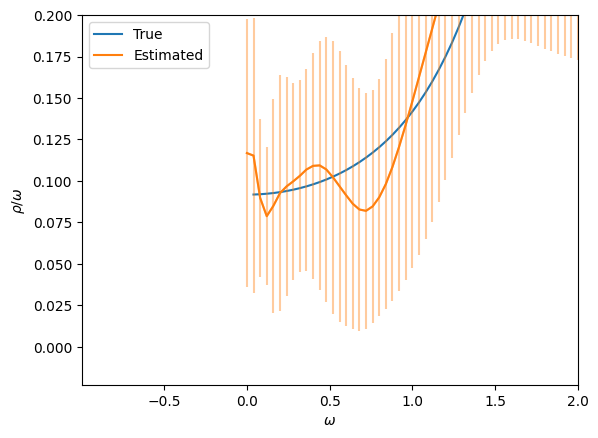

In [11]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,mean, label=r'Estimated',color='C1')
# for i in range(num_samples):
#     plt.plot(omega,np.squeeze(rho_ensemble[i]),alpha=0.2,color='gray')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C1')
plt.legend()
plt.xlim(None,2)
plt.ylim(None,0.2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


Text(0.5, 0, 'Epochs')

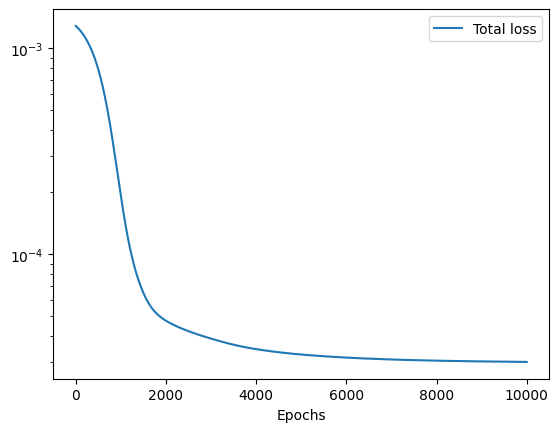

In [9]:
trainingepochs=range(10000)
total_loss_history_ensemble=np.load('data/total_loss_history_Ensemble_30_corrs_NN.npy')
loss_history_ensemble=np.load('data/loss_history_Ensemble_30_corrs_NN.npy')
plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

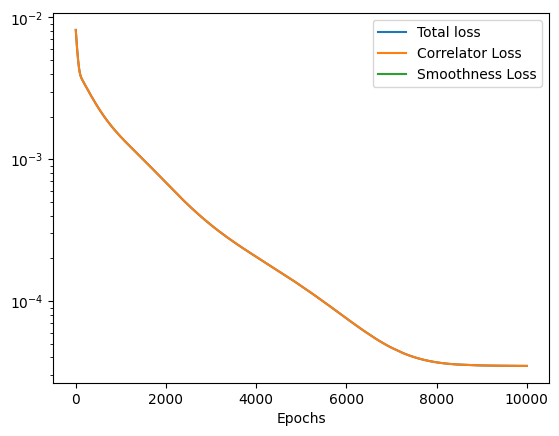

In [8]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

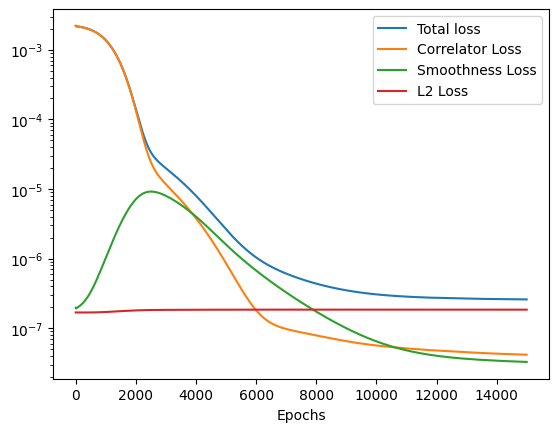

In [12]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

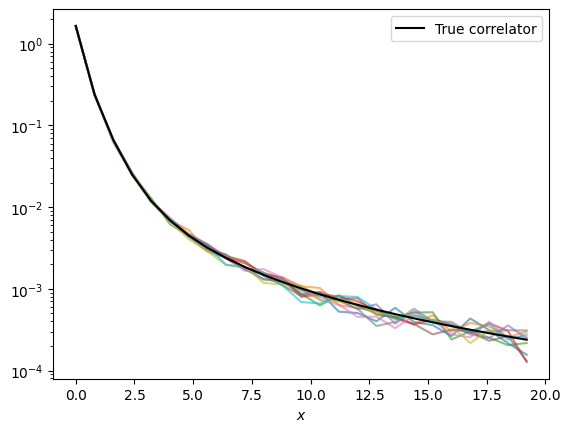

In [13]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.6)
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

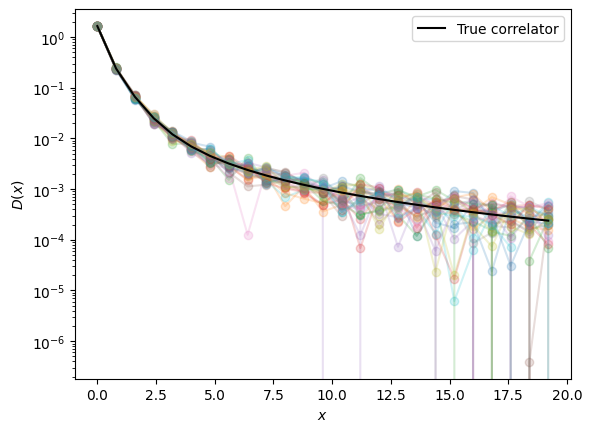

In [11]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.2,ls='-',marker='o')
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend()
plt.show()

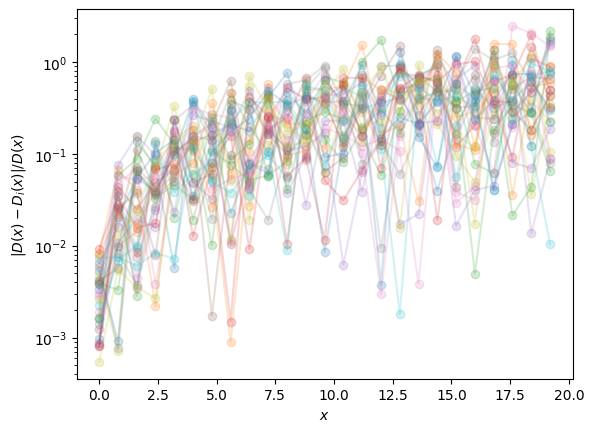

In [87]:
# relative deviation
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, np.abs(noisy_Dxi_ensemble[i]-Dxi_ensemble[0])/Dxi_ensemble[0], alpha=0.2,ls='-',marker='o')
# plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.ylabel(r'$|D(x)-D_i(x)|/D(x)$')
# plt.legend()
plt.show()

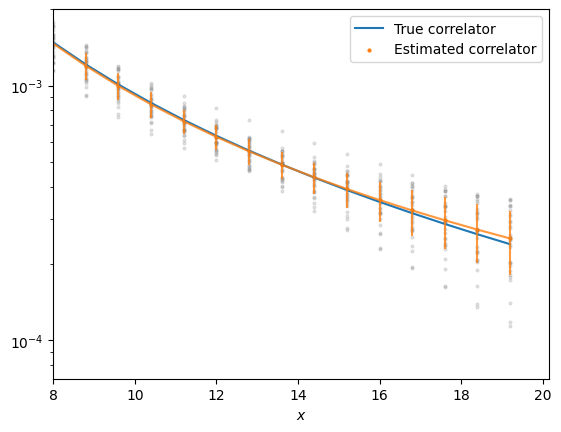

In [21]:
plt.plot(x,Dxi_ensemble[0], label=r'True correlator')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)
meanDxi=bootstrapMean(correlatorPredictions)
varDxi=bootstrapVariance(correlatorPredictions)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=0.8,color='C1')
plt.scatter(x,meanDxi, label=r'Estimated correlator',color='C1',s=4)
for i in range(num_samples):
    plt.scatter(x, correlatorPredictions[i], alpha=0.2, s=4,color='gray')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.xlim(8,None)
plt.ylim(None,2e-3)
plt.legend()
plt.show()

# Multifit vs Bootstrapped Single Fit

In [7]:
rho_ensemble=np.load('data/rho_Ensemble_30_corrs.npy')
loss_history_ensemble=np.load('data/loss_history_Ensemble_30_corrs.npy')
total_loss_history_ensemble=np.load('data/total_loss_history_Ensemble_30_corrs.npy')

rho_multifit=np.load('data/rho_Multifit_30_corrs.npy')
loss_history_multifit=np.load('data/loss_history_Multifit_30_corrs.npy')
total_loss_history_multifit=np.load('data/total_loss_history_Multifit_30_corrs.npy')

In [8]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

In [13]:
np.sqrt(bootstrapVariance(rho_ensemble))

array([[9.1777211e-03, 9.7672800e-03, 1.1500113e-02, ..., 6.6214308e-02,
        6.6214316e-02, 6.6214316e-02],
       [9.6365223e-03, 9.0384390e-03, 9.7244717e-03, ..., 6.9507375e-02,
        6.9507383e-02, 6.9507383e-02],
       [1.1274771e-02, 9.5901201e-03, 8.8937227e-03, ..., 7.3048413e-02,
        7.3048420e-02, 7.3048420e-02],
       ...,
       [6.5575182e-02, 6.8917207e-02, 7.2504975e-02, ..., 5.3517937e-08,
        5.3526406e-08, 5.3550824e-08],
       [6.5575182e-02, 6.8917215e-02, 7.2504975e-02, ..., 5.2149048e-08,
        5.2140354e-08, 5.2148547e-08],
       [6.5575182e-02, 6.8917215e-02, 7.2504975e-02, ..., 5.0834359e-08,
        5.0808122e-08, 5.0799709e-08]], dtype=float32)

/tmp/ipykernel_20825/1251255985.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True',color='black')


Text(0, 0.5, '$\\rho/\\omega$')

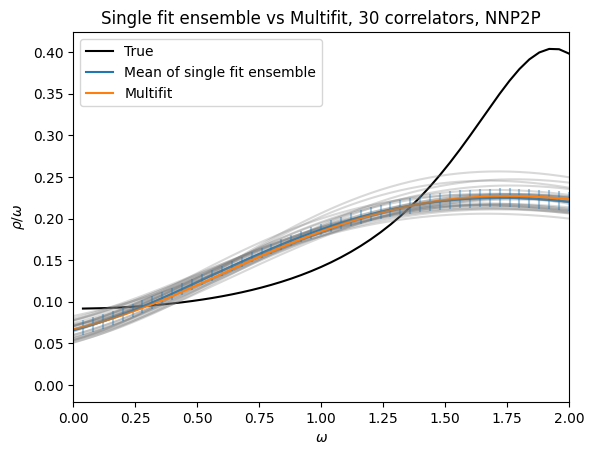

In [97]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
plt.plot(omega,spec2BW/omega, label=r'True',color='black')
plt.plot(omega,mean, label=r'Mean of single fit ensemble',color='C0')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i]),alpha=0.3,color='gray')

# plt.plot(omega,np.squeeze(rho_ensemble[24]),alpha=1.0,color='red',label=r'random sample Single fit')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C0')

plt.plot(omega,rho_multifit, label=r'Multifit',color='C1')

plt.legend()
plt.title('Single fit ensemble vs Multifit, 30 correlators, NNP2P')
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


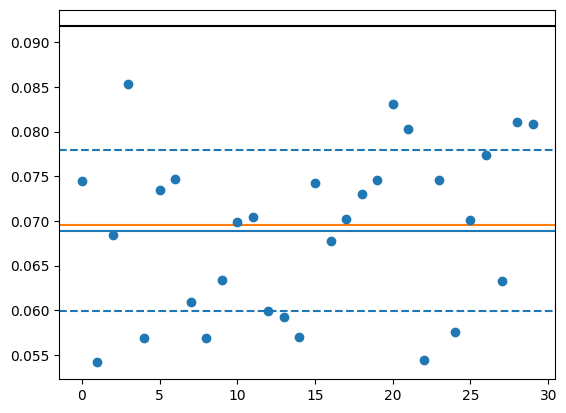

In [121]:
plt.axhline(spec2BW[1]/omega[1],color='black',ls='-')
# plt.axhline(rho_multifit[0],label='Multifit',color='C1')
plt.axhline(rho_multifit[1],color='C1')

plt.plot(rho_ensemble.T[0][1],label='Single fit ensemble',color='C0',marker='o',ls='None')
plt.axhline(mean[1],color='C0')
plt.axhline(mean[1]+np.sqrt(variance[1]),color='C0',ls='--')
plt.axhline(mean[1]-np.sqrt(variance[1]),color='C0',ls='--')



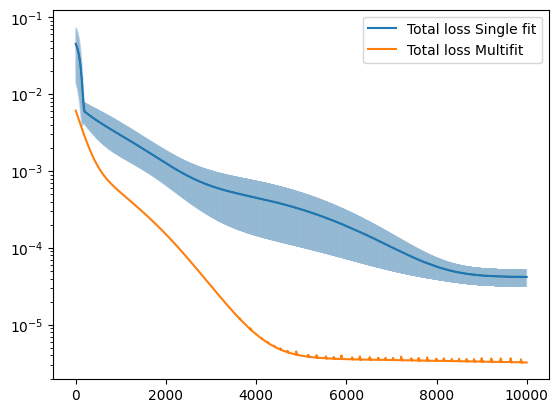

In [96]:
# Training compared to Multifit

trainingepochs=range(new_epochs)
total_loss_var=bootstrapMean(total_loss_history_ensemble)
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss Single fit',color='C0')
plt.errorbar(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),yerr=np.sqrt(bootstrapVariance(total_loss_history_ensemble)),alpha=0.01,color='C0')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss Single fit')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss Single fit')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss Single fit')

plt.plot(trainingepochs,total_loss_history_multifit,label=r'Total loss Multifit',color='C1')
# plt.plot(trainingepochs,loss_history_multifit.T[0],label=r'Correlator Loss Multifit')
# plt.plot(trainingepochs,loss_history_multifit.T[1]*lambda_s,label=r'Smoothness Loss Multifit')
# plt.plot(trainingepochs,loss_history_multifit.T[2]*0.5*lambda_l2,label=r'L2 Loss Multifit')

plt.yscale('log')
plt.legend()


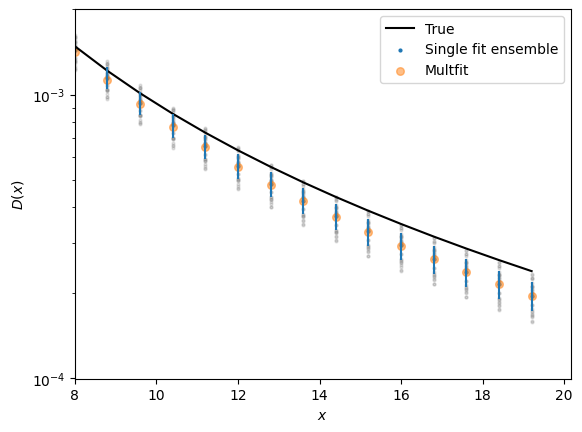

In [80]:
# compare the correlators

plt.plot(x,Dxi_ensemble[0], label=r'True',color='black')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)
meanDxi=bootstrapMean(correlatorPredictions)
varDxi=bootstrapVariance(correlatorPredictions)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=1.0,color='C0',ls='None')
plt.scatter(x,meanDxi, label=r'Single fit ensemble',color='C0',s=4)
for i in range(num_samples):
    plt.scatter(x, correlatorPredictions[i], alpha=0.2, s=4,color='gray')

Dxi_multifit=correlator.Di(klW_ker_Pos,rho_multifit,del_omega)
plt.scatter(x,Dxi_multifit, label=r'Multfit',color='C1',alpha=0.5,s=30)

plt.yscale('log')
plt.xlabel(r'$x$')
plt.xlim(8,None)
plt.ylim(None,2e-3)
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.show()

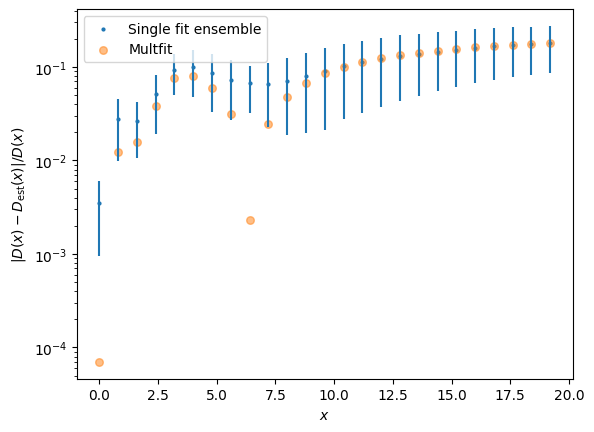

In [81]:
# compare the correlators

relativeSamples=np.abs(correlatorPredictions-Dxi_ensemble[0])/Dxi_ensemble[0]
meanrelative=bootstrapMean(relativeSamples)
varrelative=bootstrapVariance(relativeSamples)




plt.errorbar(x,meanrelative,yerr=np.sqrt(varrelative),alpha=1.0,color='C0',ls='None')
plt.scatter(x,meanrelative, label=r'Single fit ensemble',color='C0',s=4)


Dxi_multifit=correlator.Di(klW_ker_Pos,rho_multifit,del_omega)
plt.scatter(x,np.abs(Dxi_multifit-Dxi_ensemble[0])/Dxi_ensemble[0], label=r'Multfit',color='C1',alpha=0.5,s=30)

plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$|D(x)-D_{\mathrm{est}}(x)|/D(x)$')
plt.show()